**Fourier Bessel Wavelets MNIST**

Run all cells in order. Cells marked as optional don't need to be run as their outputs have been saved and opened when needed in later cells

In [1]:
from tensorflow.keras.datasets import mnist  # type: ignore
from sklearn.linear_model import SGDClassifier
import numpy as np
import umap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.ndimage import zoom
import os
import joblib

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Original x_train shape:", x_train.shape)
print("Original x_test shape:", x_test.shape)
print("Original y_train shape:", y_train.shape)
print("Original y_test shape:", y_test.shape)

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

x_train = x_train / 255.0
x_test = x_test / 255.0

Original x_train shape: (60000, 28, 28)
Original x_test shape: (10000, 28, 28)
Original y_train shape: (60000,)
Original y_test shape: (10000,)


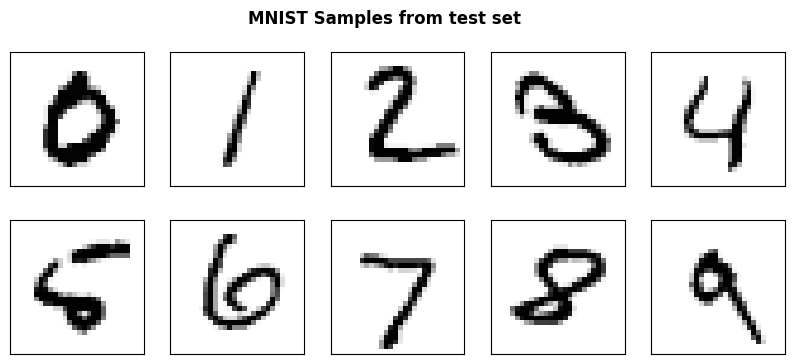

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.flatten()

for i in range(0, 10):
    X_sample_index = np.argwhere(y_test == i)[0][0]
    ax = axes[i]
    ax.imshow(x_test[X_sample_index], cmap="Greys")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("MNIST Samples from test set", fontweight="bold")
plt.show()

**Create wavelet bank, scatnet**

In [7]:
from fbscatnet import FourierBesselWaveletBank, FourierBesselScatNet, logger_config
import logging
logger_config.enable_colored_logs(logging.DEBUG)
bank = FourierBesselWaveletBank(28, 5, 5, 0.3, 'l1', True)
m, k, sig = bank.summary()

DOWNSAMPLE_F = 4

model = FourierBesselScatNet(bank)

2026-07-29 14:27:23 [INFO] Low pass  (m=0, k=0) | Mean (>0): 4.70e-02 | L1: 1.0000
2026-07-29 14:27:23 [INFO] Wavelet (m=0, k=1) | Mean (~0): 1.45e-01 | L1: 1.0000 | Eigenvalue: 3.8317
2026-07-29 14:27:23 [INFO] Wavelet (m=1, k=1) | Mean (~0): 1.69e-17 | L1: 1.0000 | Eigenvalue: 1.8412
2026-07-29 14:27:23 [INFO] Wavelet (m=0, k=2) | Mean (~0): 2.16e-01 | L1: 1.0000 | Eigenvalue: 7.0156
2026-07-29 14:27:23 [INFO] Wavelet (m=1, k=2) | Mean (~0): 1.26e-17 | L1: 1.0000 | Eigenvalue: 5.3314
2026-07-29 14:27:23 [INFO] Wavelet (m=2, k=2) | Mean (~0): 8.90e-19 | L1: 1.0000 | Eigenvalue: 3.0542
2026-07-29 14:27:23 [INFO] Wavelet (m=0, k=3) | Mean (~0): 3.31e-01 | L1: 1.0000 | Eigenvalue: 10.1735
2026-07-29 14:27:23 [INFO] Wavelet (m=1, k=3) | Mean (~0): 2.07e-17 | L1: 1.0000 | Eigenvalue: 8.5363
2026-07-29 14:27:23 [INFO] Wavelet (m=2, k=3) | Mean (~0): 4.85e-18 | L1: 1.0000 | Eigenvalue: 6.7061
2026-07-29 14:27:23 [INFO] Wavelet (m=3, k=3) | Mean (~0): 1.95e-17 | L1: 1.0000 | Eigenvalue: 4.201

**Visualise bank**

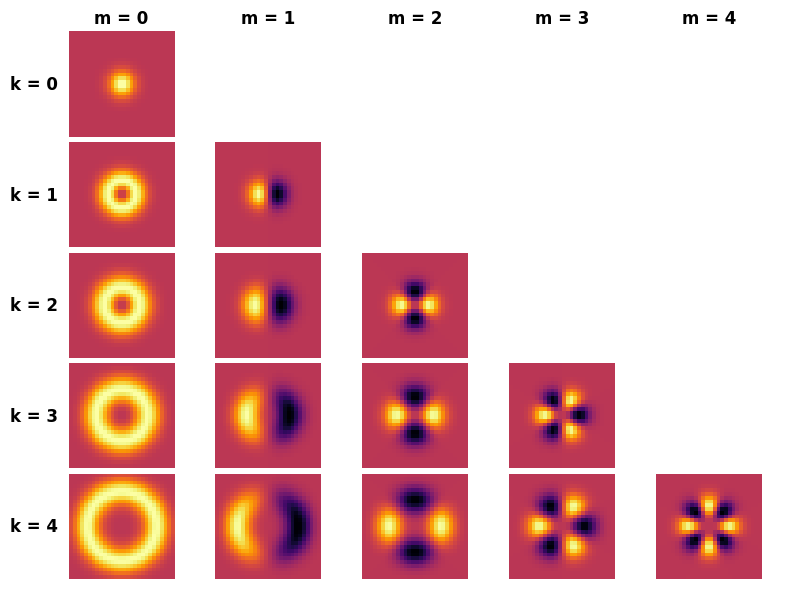

In [5]:
bank.plot_bank()

**Description of the convolution process**

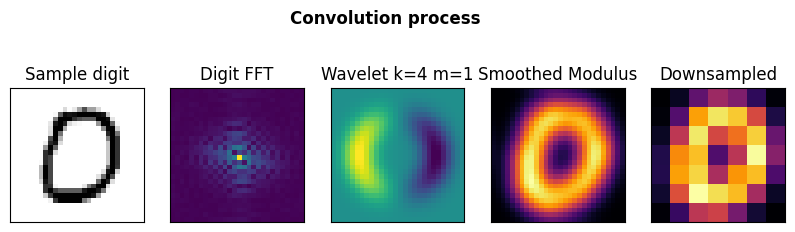

In [6]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

for axe in ax:
    axe.set_xticks([])
    axe.set_yticks([])

# Sample digit and wavelet
sample_idx = 10
sample_m = 1
sample_k = 4
low_pass = bank[0, 0]

# Original digit
ax[0].imshow(x_test[sample_idx], cmap="Greys")
ax[0].set_title("Sample digit")

# Fourier digit
fft_digit = np.fft.fftshift(np.fft.fft2(x_test[sample_idx]))
ax[1].imshow(np.abs(fft_digit))
ax[1].set_title("Digit FFT")

# Fourier wavelet
fft_filter = bank[1, 4]
ax[2].imshow(np.real(fft_filter), cmap="viridis")
ax[2].set_title(f"Wavelet k={sample_k} m={sample_m}")

# 1. Convolve in frequency and shift back for IFFT
shifted_freq = np.fft.ifftshift(fft_digit * fft_filter)

# 2. IFFT to spatial and take the modulus envelope
spatial_complex = np.fft.ifft2(shifted_freq)
modulus_spatial = np.abs(spatial_complex)

# 3. FFT back to frequency (centered) to apply low-pass
modulus_fft = np.fft.fftshift(np.fft.fft2(modulus_spatial))
filtered_low_pass = modulus_fft * low_pass

# 4. IFFT back to spatial for final viewing
smoothed_spatial = np.real(np.fft.ifft2(np.fft.ifftshift(filtered_low_pass)))

ax[3].imshow(smoothed_spatial, cmap="inferno")
ax[3].set_title("Smoothed Modulus")

# Downsampled final version
output_map = smoothed_spatial.reshape(
    int(28 / DOWNSAMPLE_F), DOWNSAMPLE_F, int(28 / DOWNSAMPLE_F), DOWNSAMPLE_F
).mean(axis=(1, 3))

ax[4].imshow(output_map, cmap="inferno")
ax[4].set_title("Downsampled")

plt.suptitle("Convolution process", fontweight="bold")
plt.show()

**Low pass and first order visualisation**

Notice how each map highlights a different edge of the digit

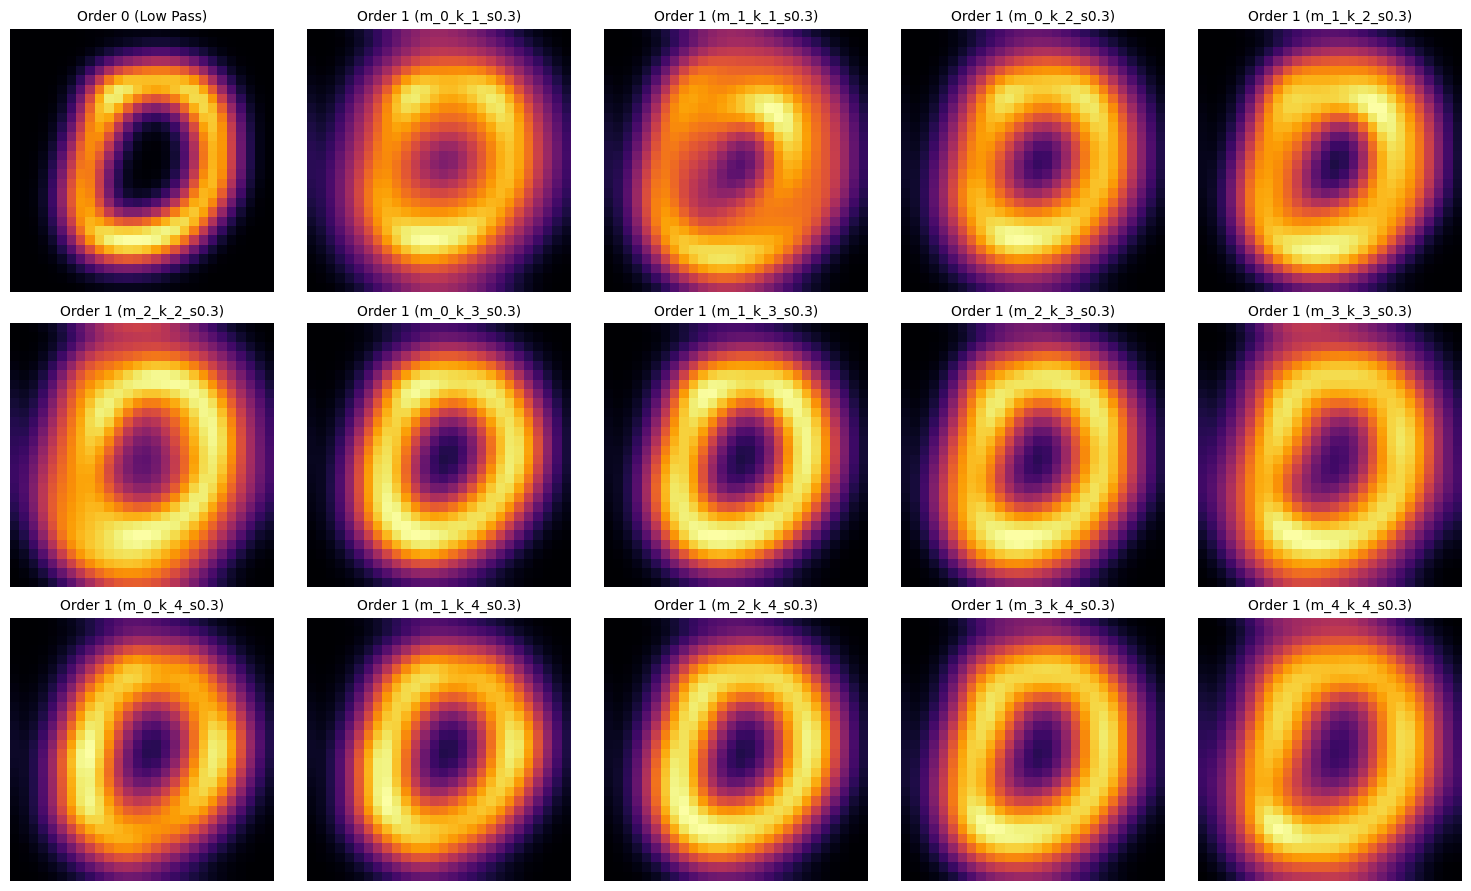

In [7]:
model.visualise_maps(x_test[sample_idx], 1)

**Feature extraction loop - Optional cell**

Features are already saved to repo so no need to run. Otherwise takes around 8 mins to run depending on device

In [8]:
# Run the batched extraction
os.makedirs('features', exist_ok=True)

print("\n--- Processing Training Set ---")
X_train_svc = model.generate_embeddings(x_train, 4, 200)
model.save_embeddings('features/mnist_example_train_embeddings')

print("\n--- Processing Test Set ---")
X_test_svc = model.generate_embeddings(x_test, 4, 200)
model.save_embeddings('features/mnist_example_test_embeddings')

print("\nFeature extraction and pooling complete!")
print("Final X_train_svm shape:", X_train_svc.shape)
print("Final X_test_svm shape:", X_test_svc.shape)


--- Processing Training Set ---


Generating Embeddings on CPU:   0%|          | 0/300 [00:00<?, ?batch/s]

Generating Embeddings on CPU: 100%|██████████| 300/300 [06:24<00:00,  1.28s/batch]


2026-07-28 13:06:17 [INFO] Embedding successfully saved to 'features/mnist_example_train_embeddings/embedding_m5_k5_sigma0.3.npz'

--- Processing Test Set ---


Generating Embeddings on CPU: 100%|██████████| 50/50 [01:11<00:00,  1.43s/batch]


2026-07-28 13:07:41 [INFO] Embedding successfully saved to 'features/mnist_example_test_embeddings/embedding_m5_k5_sigma0.3.npz'

Feature extraction and pooling complete!
Final X_train_svm shape: (60000, 4214)
Final X_test_svm shape: (10000, 4214)


**Feature scaling/normalisation**

Make sure you run the first two cells if starting from here

In [3]:
with np.load('features/mnist_example_train_embeddings/embedding_m5_k5_sigma0.3.npz') as data:
    X_train_svc = data['embedding'] 

with np.load('features/mnist_example_test_embeddings/embedding_m5_k5_sigma0.3.npz') as data:
    X_test_svc = data['embedding'] 

X_train_log = np.log1p(X_train_svc)
X_test_log = np.log1p(X_test_svc)

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_log)
X_test_final = scaler.transform(X_test_log)

**UMAP Projection**

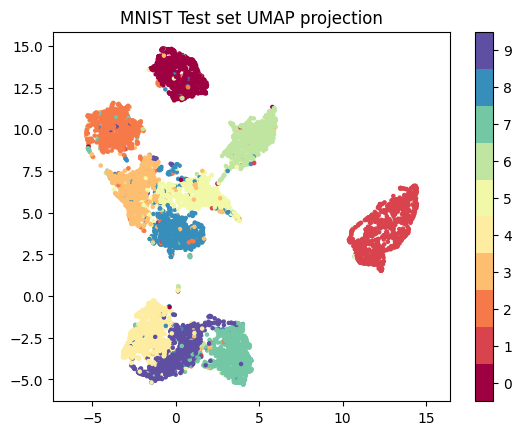

In [ ]:
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, random_state=42, n_jobs=1)
embedding = reducer.fit_transform(X_test_final)

plt.scatter(embedding[:, 0], embedding[:, 1], c=y_test, cmap="Spectral", s=5) # type: ignore
plt.gca().set_aspect("equal", "datalim")
plt.colorbar(boundaries=np.arange(11) - 0.5).set_ticks(np.arange(10))  # type: ignore
plt.title("MNIST Test set UMAP projection")
plt.show()

**PCA Analysis**

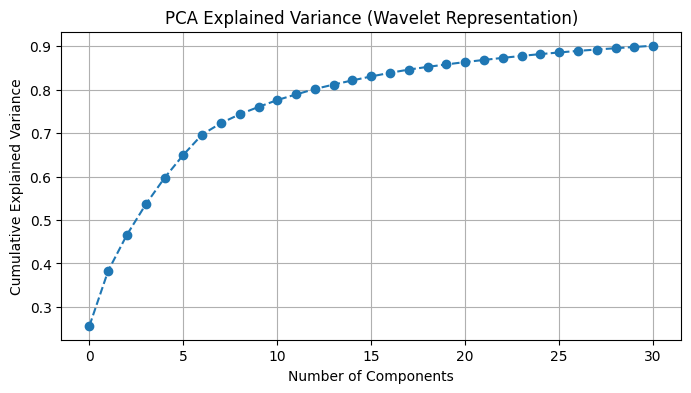

Original feature size: 4214
Reduced feature size: 31


In [5]:
reducer = PCA(n_components=0.90)
reducer.fit(X_train_final)

X_train_pca = reducer.transform(X_train_final)
X_test_pca = reducer.transform(X_test_final)

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(reducer.explained_variance_ratio_), marker="o", linestyle="--")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance (Wavelet Representation)")
plt.grid(True)
plt.show()

print(f"Original feature size: {X_train_final.shape[1]}")
print(f"Reduced feature size: {X_train_pca.shape[1]}")

**Model fitting - Optional cell**

We fit a simple classifier for the purpose of this example. This allows for interpretable weights and rapid training

Training..
Testing..
Saving model..
Model saved successfully!

--- Final Classification Report ---
              precision    recall  f1-score   support

           0     0.9653    0.9929    0.9789       980
           1     0.9767    0.9956    0.9860      1135
           2     0.9690    0.9700    0.9695      1032
           3     0.9740    0.9653    0.9697      1010
           4     0.9796    0.9786    0.9791       982
           5     0.9729    0.9652    0.9690       892
           6     0.9822    0.9770    0.9796       958
           7     0.9725    0.9650    0.9688      1028
           8     0.9632    0.9682    0.9657       974
           9     0.9766    0.9514    0.9639      1009

    accuracy                         0.9732     10000
   macro avg     0.9732    0.9729    0.9730     10000
weighted avg     0.9732    0.9732    0.9732     10000



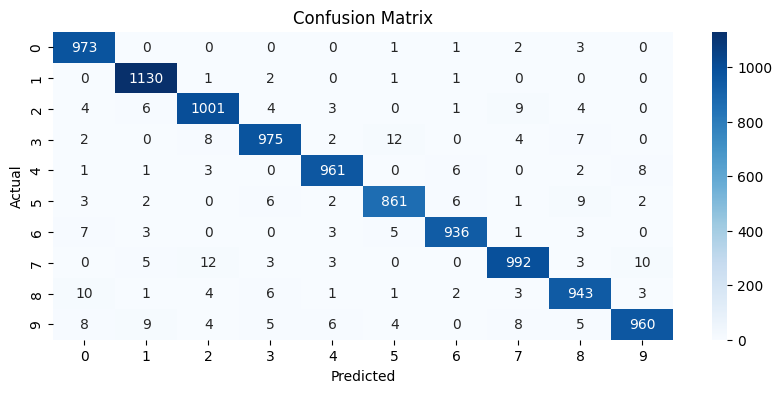

In [5]:
base_model = SGDClassifier(
    loss="squared_hinge", 
    penalty="l2", 
    max_iter=3000, 
    random_state=42, 
    n_jobs=-1  
)

print("Training..")
base_model.fit(X_train_final, y_train)

print("Testing..")
preds = base_model.predict(X_test_final)

print("Saving model..")
os.makedirs('models', exist_ok=True)
joblib.dump(base_model, "models/base_model.pkl")
print("Model saved successfully!")

print("\n--- Final Classification Report ---")
print(classification_report(y_test, preds, digits=4))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix")
plt.show()